# BOLD -> FFT -> Hilbert pipeline

This notebook follows the full preprocessing path for one subject and one focus ROI:

1. raw BOLD signal
2. FFT band-pass filtering
3. Hilbert analytic signal, envelope, and phase


In [1]:
from pathlib import Path
import sys
import torch

import matplotlib.pyplot as plt
import numpy as np
import scienceplots
# plt.style.use('science')

project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.dataset import load_mat_data, fft_bandpass_3d, hilbert_transform
from src.utils import prepare_signal_pipeline, plot_signal_pipeline

def _to_numpy(x: torch.Tensor | np.ndarray) -> np.ndarray:
    if isinstance(x, np.ndarray):
        return x
    return x.detach().cpu().numpy()

plt.rcParams["figure.dpi"] = 140
%matplotlib inline

In [40]:
dataset_path = project_root / "data" / "ts_young" / "ts_young_TR0.72.mat"
subject_index = 0
roi_indices = [0, 49, 99]
focus_roi = 25
dt = 0.72
f_lo, f_hi = 0.008, 0.08
w, h = 4, 2
v_lim = 2.5
max_timepoints = 200

data = load_mat_data(str(dataset_path))
raw_timeseries = data["timeseries_all"].transpose(2, 0, 1)


print(f"dataset: {dataset_path}")
print(f"subjects x rois x timepoints: {raw_timeseries.shape}")


dataset: /home/id94ebid/projects/neuroscience_control/data/ts_young/ts_young_TR0.72.mat
subjects x rois x timepoints: (94, 100, 1200)


In [41]:
ts = torch.as_tensor(raw_timeseries)
time = np.arange(max_timepoints, dtype=np.float32) * dt

subject_ts = ts[subject_index : subject_index + 1]
mean = subject_ts.mean(dim=2, keepdim=True)
std = subject_ts.std(dim=2, keepdim=True) + 1e-8
normalized = (subject_ts - mean) / std

filtered = fft_bandpass_3d(normalized, dt=dt, f_lo=f_lo, f_hi=f_hi)
analytic = hilbert_transform(filtered)

real = _to_numpy(normalized[0, roi_indices, :max_timepoints])
filtered = _to_numpy(filtered[0, roi_indices, :max_timepoints])
analytic = _to_numpy(analytic[0, roi_indices, :max_timepoints])
normalized = _to_numpy(normalized[0, roi_indices, :max_timepoints])

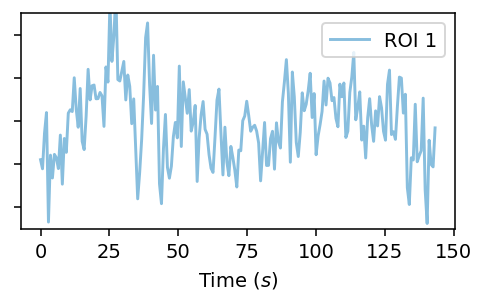

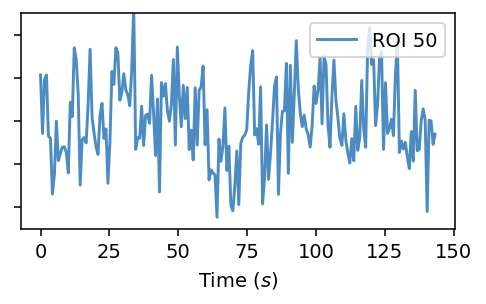

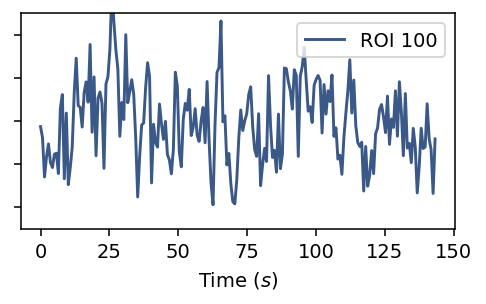

In [47]:
# Colormap for ROIs

cmap = plt.cm.Blues
colors = cmap(np.linspace(0.5, 1, len(roi_indices)))

for i, roi in enumerate(roi_indices):
    fig, ax = plt.subplots(figsize=(w, h))
    plt.plot(time, normalized[i], label=f"ROI {roi+1}", alpha=0.8, color=colors[i])
    #ax.set_title(f"Subject {pipeline.subject_index}, ROI {roi}")
    ax.set_yticklabels([]); #ax.set_yticks([-1, 0, 1]);
    ax.set_ylim(-v_lim,v_lim)
    #ax.set_xticks([]); ax.set_xticklabels([])
    plt.legend(loc="upper right")
    ax.set_xlabel("Time ($s$)")
    plt.savefig(project_root / "paper" / "images" / "representation" / f"raw_timeseries_roi{roi}.svg", dpi=100, bbox_inches="tight")

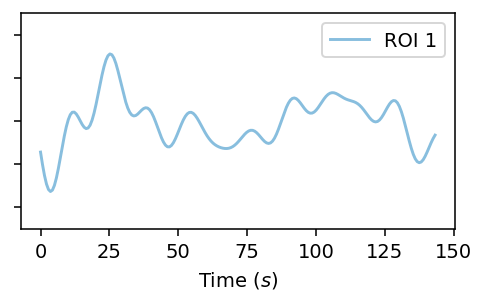

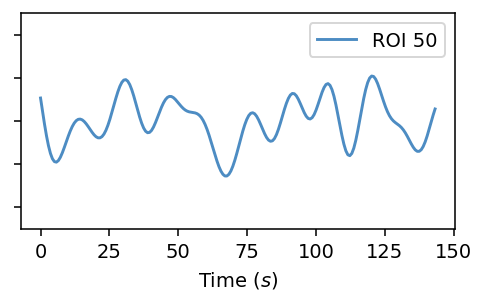

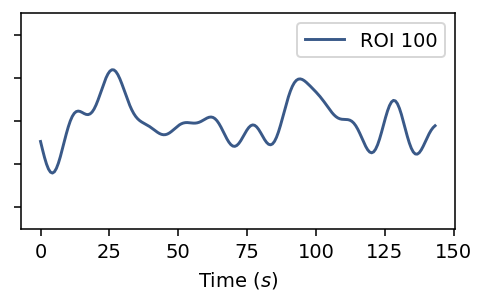

In [48]:
# Colormap for ROIs

cmap = plt.cm.Blues
colors = cmap(np.linspace(0.5, 1, len(roi_indices)))

for i, roi in enumerate(roi_indices):
    fig, ax = plt.subplots(figsize=(w, h))
    plt.plot(time, filtered[i], label=f"ROI {roi+1}", alpha=0.8, color=colors[i])
    #ax.set_title(f"Subject {pipeline.subject_index}, ROI {roi}")
    ax.set_yticklabels([]); #ax.set_yticks([])
    ax.set_ylim(-v_lim,v_lim)
    # ax.set_xticks([]); ax.set_xticklabels([])
    ax.set_xlabel("Time ($s$)")
    plt.legend(loc="upper right")
    plt.savefig(project_root / "paper" / "images" / "representation" / f"filtered_timeseries_roi{roi}.svg", dpi=100, bbox_inches="tight")

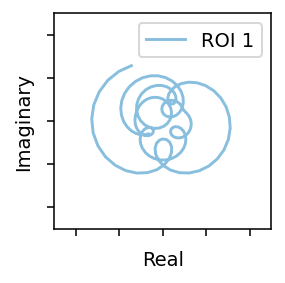

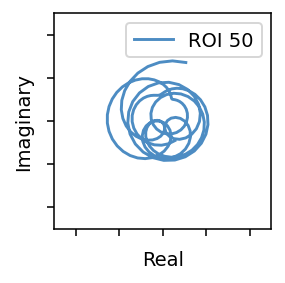

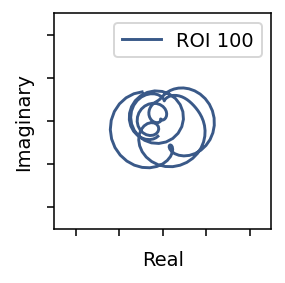

In [49]:

cmap = plt.cm.Blues
colors = cmap(np.linspace(0.5, 1, len(roi_indices)))

for i, roi in enumerate(roi_indices):
    fig, ax = plt.subplots(figsize=(h, h))
    plt.plot(analytic[i].real, analytic[i].imag, label=f"ROI {roi+1}", alpha=0.8, color=colors[i])
    #ax.set_title(f"Subject {pipeline.subject_index}, ROI {roi}")
    ax.set_yticklabels([]); ax.set_xticklabels([])
    ax.set_xticks([-2, -1, 0, 1, 2]); ax.set_yticks([-2, -1, 0, 1, 2])
    ax.set_ylim(-v_lim, v_lim); ax.set_xlim(-v_lim, v_lim)
    ax.set_xlabel("Real"); ax.set_ylabel("Imaginary")

    ax.set_xticklabels([])
    plt.legend(loc="upper right")
    plt.savefig(project_root / "paper" / "images" / "representation" / f"analytic_timeseries_roi{roi}.svg", dpi=100, bbox_inches="tight")

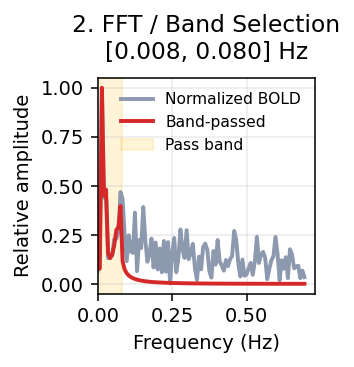

In [45]:
raw_spectrum = np.abs(np.fft.rfft(real[0]))
filtered_spectrum=np.abs(np.fft.rfft(filtered[0]))
frequencies=np.fft.rfftfreq(max_timepoints, d=dt)

fig, ax = plt.subplots(figsize=(h, h))
raw_spec = raw_spectrum / (raw_spectrum.max() + 1e-8)
filtered_spec = filtered_spectrum / (filtered_spectrum.max() + 1e-8)
ax.plot(frequencies, raw_spec, color="#8d99ae", linewidth=2.0, label="Normalized BOLD")
ax.plot(
    frequencies,
    filtered_spec,
    color="#d62828",
    linewidth=2.0,
    label="Band-passed",
)
ax.axvspan(f_lo, f_hi, color="#ffd166", alpha=0.25, label="Pass band")
ax.set_title(f"2. FFT / Band Selection\n[{f_lo:.3f}, {f_hi:.3f}] Hz", fontsize=12, pad=10)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Relative amplitude")
ax.set_xlim(left=0.0)
ax.grid(True, alpha=0.25)
ax.legend(loc="upper right", fontsize=8, frameon=False)
plt.savefig(project_root / "paper" / "images" / "representation" / f"Band_pass.svg", dpi=100, bbox_inches="tight")

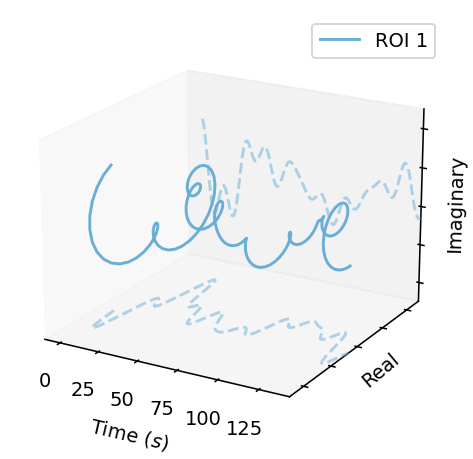

In [46]:
# Make a 3d plot of the analytic signal 
from mpl_toolkits.mplot3d.axes3d import Axes3D
id = 0
fig = plt.figure(figsize=(int(3*w), int(w)))
ax = fig.add_subplot(111, projection='3d')
ax.plot(time, analytic[id].real, analytic[id].imag, linewidth=1.5, label=f"ROI {roi_indices[id]+1}", alpha=1.0, color=colors[id])
ax.plot(time, v_lim, analytic[id].imag, alpha=0.5, color=colors[id], linestyle='--') # for setting the zlim
ax.plot(time, analytic[id].real, -v_lim, alpha=0.5, color=colors[id], linestyle='--') # for setting the zlim
# Remove the grid and leave the horizontal lines only
ax.grid(False)   
ax.set_yticklabels([]); ax.set_zticklabels([])
ax.set_zticks([-2, -1, 0, 1, 2])
#ax.set_zticklabels(["-2i", "-i", "0", "i", "2i"])
ax.set_yticks([-2, -1, 0, 1, 2])
#ax.set_yticklabels(["-2", "-1", "0", "1", "2"])
ax.set_ylim(-v_lim, v_lim)
ax.set_zlim(-v_lim, v_lim)
ax.set_xlim(time[0]-10, time[-1])
# ax.set_xticklabels([])
ax.set_xlabel("Time ($s$)", labelpad=5)
ax.set_ylabel("Real", labelpad=-10, rotation=40)
ax.set_zlabel("Imaginary", rotation=90, labelpad=-10)
ax.view_init(elev=20, azim=-60)
#ax.set_yticklabels([])
#ax.set_zticklabels([])
# x_scale=1
# y_scale=1
# z_scale=1

# scale=np.diag([x_scale, y_scale, z_scale, 1.0])
# scale=scale*(1.0/scale.max())
# scale[3,3]=1.0

# def short_proj():
#   return np.dot(Axes3D.get_proj(ax), scale)

# ax.get_proj=short_proj

# for z_val in [-2, -1, 0, 1, 2]:
#     ax.plot([time[0], time[-1]], [v_lim, v_lim], [z_val, z_val],
#             color='k', alpha=0.4, linewidth=.5, zorder=0)
#     ax.plot([time[0], time[-1]], [z_val, z_val], [-v_lim,-v_lim],
#             color='k', alpha=0.4, linewidth=.5, zorder=0)
    


plt.legend(loc="upper right")
plt.savefig(project_root / "paper" / "images" / "representation" / f"analytic_signal.svg", dpi=100, bbox_inches="tight")

In [9]:
fig = plot_signal_pipeline(pipeline)
plt.show()


NameError: name 'pipeline' is not defined